___

<a href='http://www.pieriandata.com'> <img src='../Pierian_Data_Logo.png' /></a>
___
# Logistic Regression Project 

In this project we will be working with a fake advertising data set, indicating whether or not a particular internet user clicked on an Advertisement. We will try to create a model that will predict whether or not they will click on an ad based off the features of that user.

This data set contains the following features:

* 'Daily Time Spent on Site': consumer time on site in minutes
* 'Age': cutomer age in years
* 'Area Income': Avg. Income of geographical area of consumer
* 'Daily Internet Usage': Avg. minutes a day consumer is on the internet
* 'Ad Topic Line': Headline of the advertisement
* 'City': City of consumer
* 'Male': Whether or not consumer was male
* 'Country': Country of consumer
* 'Timestamp': Time at which consumer clicked on Ad or closed window
* 'Clicked on Ad': 0 or 1 indicated clicking on Ad

## Import Libraries

**Import a few libraries you think you'll need (Or just import them as you go along!)**

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st

## Get the Data
**Read in the advertising.csv file and set it to a data frame called ad_data.**

In [11]:
ad_data = pd.read_csv("advertising.csv")

In [12]:
st.mean(ad_data['Area Income'])

55000.00008

In [13]:
st.mode(ad_data["Area Income"])
st.quantiles

<function statistics.quantiles(data, *, n=4, method='exclusive')>

In [14]:
# DO NOT EDIT THE FOLLOWING 2 LINES
import numpy as np
data = np.arange(1, 41).reshape(4, 10)

#############################
# Enter your solution below #
#############################
print(data)
my_slice = data[1:3, 3:7]
print(my_slice)

[[ 1  2  3  4  5  6  7  8  9 10]
 [11 12 13 14 15 16 17 18 19 20]
 [21 22 23 24 25 26 27 28 29 30]
 [31 32 33 34 35 36 37 38 39 40]]
[[14 15 16 17]
 [24 25 26 27]]


In [15]:
numericCols = ad_data.select_dtypes(['number'])
st.mean(numericCols)

TypeError: can't convert type 'str' to numerator/denominator

**Check the head of ad_data**

In [ ]:
ad_data.head(5)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


** Use info and describe() on ad_data**

In [ ]:
ad_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [ ]:
ad_data.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
Daily Time Spent on Site    1000 non-null float64
Age                         1000 non-null int64
Area Income                 1000 non-null float64
Daily Internet Usage        1000 non-null float64
Ad Topic Line               1000 non-null object
City                        1000 non-null object
Male                        1000 non-null int64
Country                     1000 non-null object
Timestamp                   1000 non-null object
Clicked on Ad               1000 non-null int64
dtypes: float64(3), int64(3), object(4)
memory usage: 78.2+ KB


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


## Exploratory Data Analysis

Let's use seaborn to explore the data!

Try recreating the plots shown below!

** Create a histogram of the Age**

<Axes: xlabel='Age', ylabel='Count'>

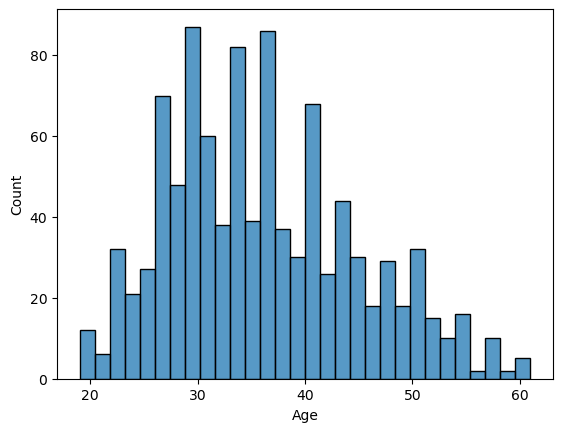

In [ ]:
sns.histplot(x='Age', data=ad_data, bins=30)

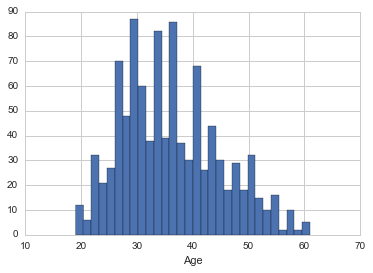

**Create a jointplot showing Area Income versus Age.**

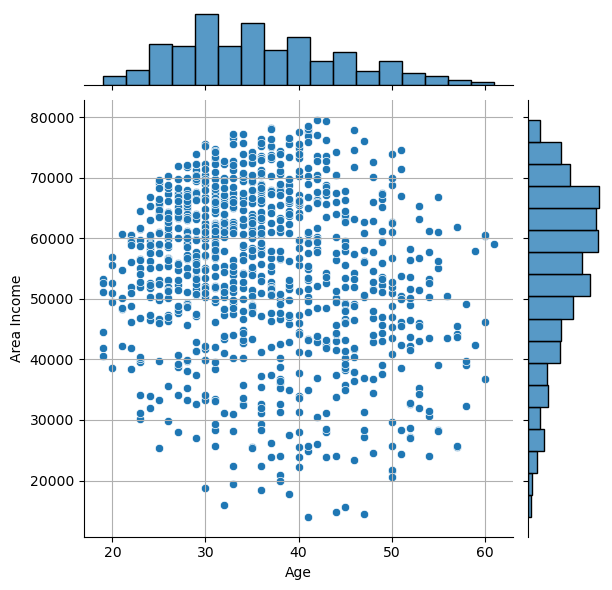

In [ ]:
sns.jointplot(y='Area Income', x='Age', data=ad_data)
plt.grid()

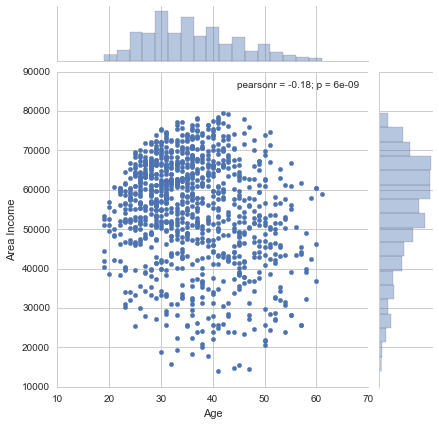

**Create a jointplot showing the kde distributions of Daily Time spent on site vs. Age.**

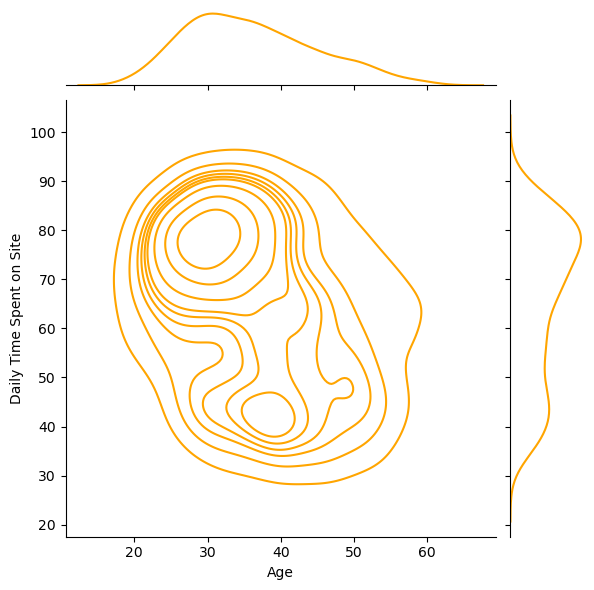

In [ ]:
sns.jointplot(y='Daily Time Spent on Site', x='Age', data=ad_data, kind='kde', color='orange')

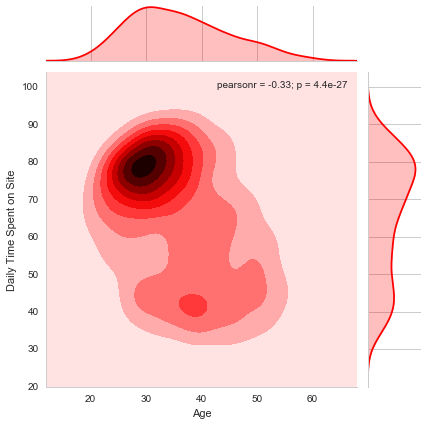

** Create a jointplot of 'Daily Time Spent on Site' vs. 'Daily Internet Usage'**

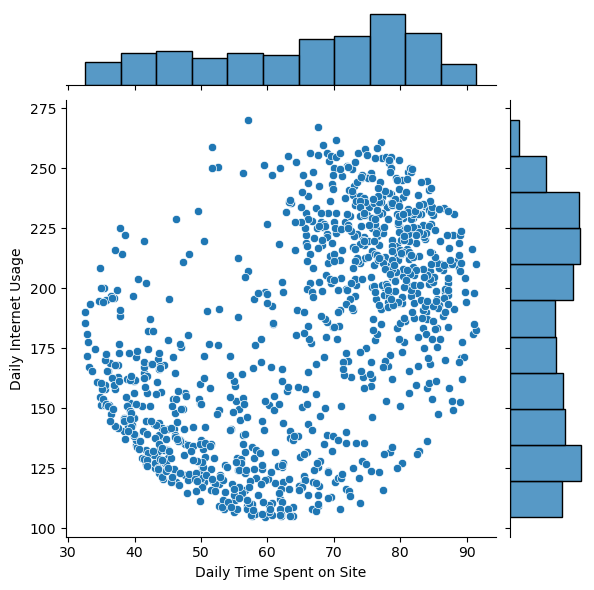

In [ ]:
sns.jointplot(y='Daily Internet Usage', x='Daily Time Spent on Site', kind='scatter', data=ad_data)

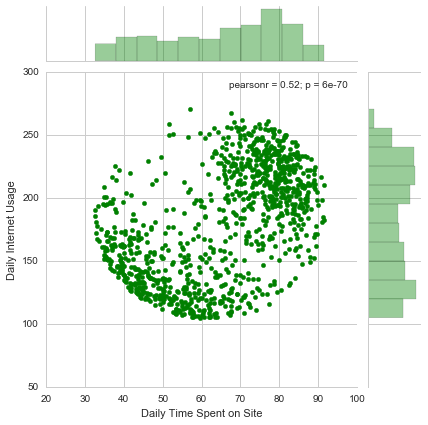

** Finally, create a pairplot with the hue defined by the 'Clicked on Ad' column feature.**

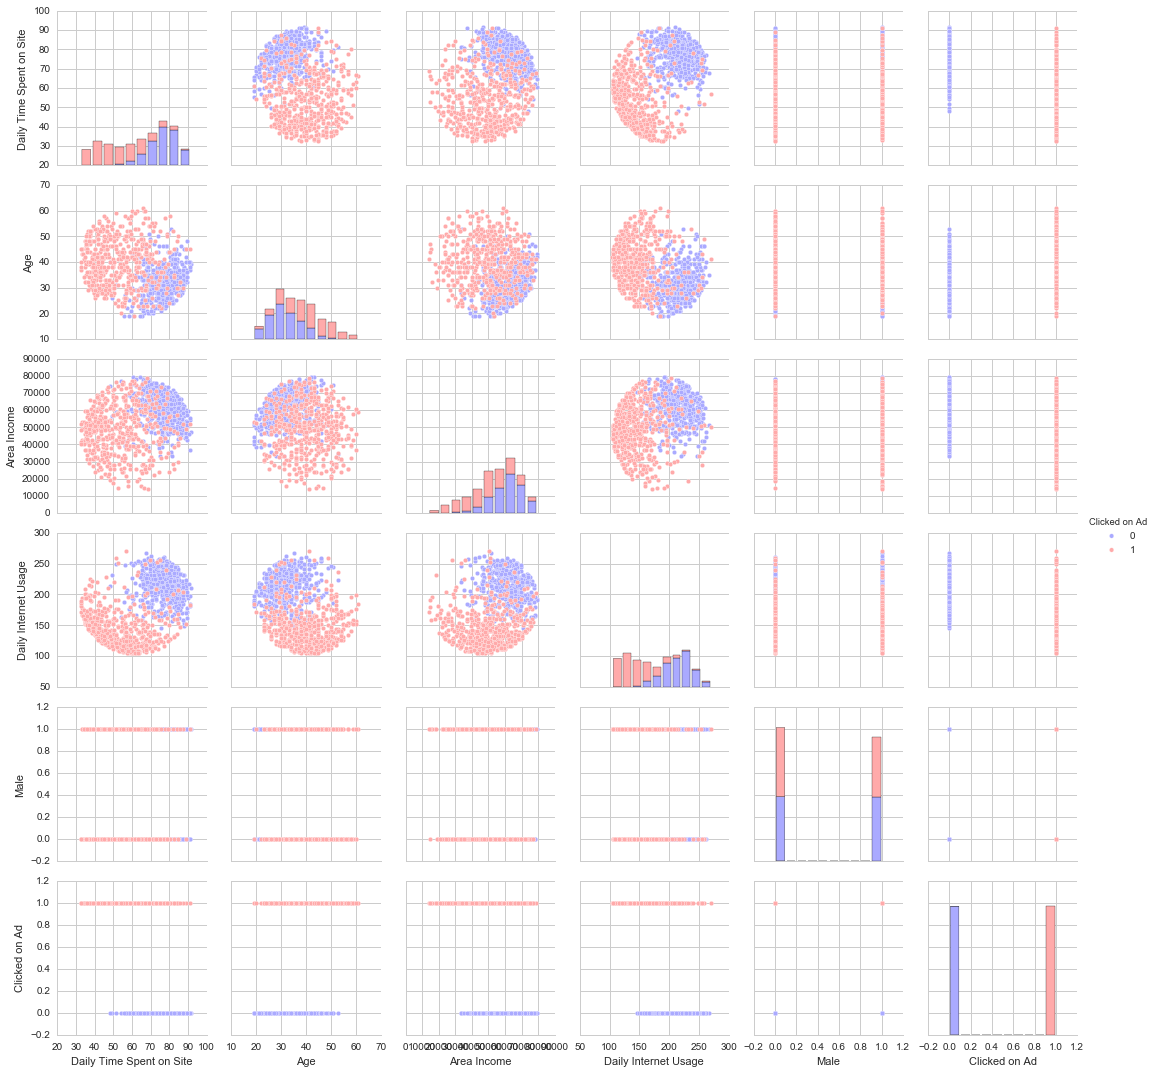

# Logistic Regression

Now it's time to do a train test split, and train our model!

You'll have the freedom here to choose columns that you want to train on!

** Split the data into training set and testing set using train_test_split**

<Axes: >

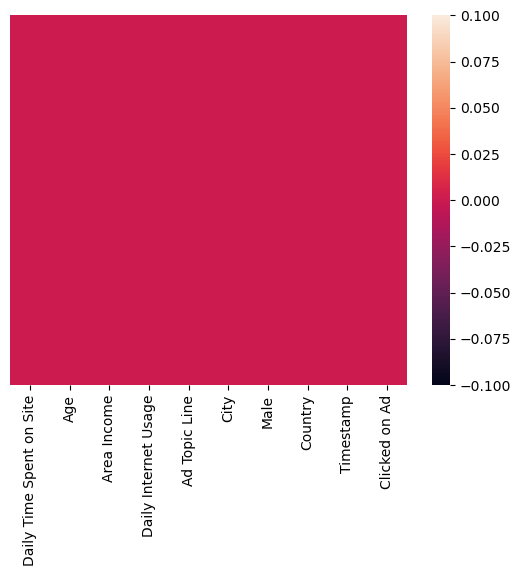

In [ ]:
sns.heatmap(ad_data.isnull(), yticklabels=False)

In [26]:
city = pd.get_dummies(ad_data['City'], drop_first=True)
country = pd.get_dummies(ad_data['Country'],drop_first=True)

In [29]:
ad_data = pd.concat([ad_data, city, country], axis=1)

In [30]:
ad_data.drop(['City', 'Country'], inplace=True, axis=1)

In [31]:
ad_data.drop('Ad Topic Line', inplace=True, axis=1)


In [32]:
ad_data['Timestamp'] = pd.to_datetime(ad_data['Timestamp'])

In [33]:
type(ad_data['Timestamp'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [34]:
ad_data

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Timestamp,Clicked on Ad,Adamside,Adamsstad,Alanview,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,Wallis and Futuna,Western Sahara,Yemen,Zambia,Zimbabwe
0,68.95,35,61833.90,256.09,0,2016-03-27 00:53:11,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,80.23,31,68441.85,193.77,1,2016-04-04 01:39:02,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,69.47,26,59785.94,236.50,0,2016-03-13 20:35:42,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,74.15,29,54806.18,245.89,1,2016-01-10 02:31:19,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,68.37,35,73889.99,225.58,0,2016-06-03 03:36:18,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,72.97,30,71384.57,208.58,1,2016-02-11 21:49:00,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
996,51.30,45,67782.17,134.42,1,2016-04-22 02:07:01,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
997,51.63,51,42415.72,120.37,1,2016-02-01 17:24:57,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
998,55.55,19,41920.79,187.95,0,2016-03-24 02:35:54,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18
...,...,...,...,...,...,...,...,...,...
995,72.97,30,71384.57,208.58,Fundamental modular algorithm,Duffystad,1,Lebanon,2016-02-11 21:49:00
996,51.30,45,67782.17,134.42,Grass-roots cohesive monitoring,New Darlene,1,Bosnia and Herzegovina,2016-04-22 02:07:01
997,51.63,51,42415.72,120.37,Expanded intangible solution,South Jessica,1,Mongolia,2016-02-01 17:24:57
998,55.55,19,41920.79,187.95,Proactive bandwidth-monitored policy,West Steven,0,Guatemala,2016-03-24 02:35:54


In [ ]:
feature = ad_data.columns.to_list
# feature
# ad_data

# X_train.info()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Timestamp,Clicked on Ad,Adamside,Adamsstad,Alanview,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,Wallis and Futuna,Western Sahara,Yemen,Zambia,Zimbabwe
0,68.95,35,61833.90,256.09,0,2016-03-27 00:53:11,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,80.23,31,68441.85,193.77,1,2016-04-04 01:39:02,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,69.47,26,59785.94,236.50,0,2016-03-13 20:35:42,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,74.15,29,54806.18,245.89,1,2016-01-10 02:31:19,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,68.37,35,73889.99,225.58,0,2016-06-03 03:36:18,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,72.97,30,71384.57,208.58,1,2016-02-11 21:49:00,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
996,51.30,45,67782.17,134.42,1,2016-04-22 02:07:01,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
997,51.63,51,42415.72,120.37,1,2016-02-01 17:24:57,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
998,55.55,19,41920.79,187.95,0,2016-03-24 02:35:54,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(ad_data.drop(['Clicked on Ad', 'Timestamp'], axis=1), 
                                                    ad_data['Clicked on Ad'], test_size=0.2, random_state=101)

** Train and fit a logistic regression model on the training set.**

In [42]:
from sklearn.linear_model import LogisticRegression
logReg = LogisticRegression(max_iter=10000)
logReg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)

## Predictions and Evaluations
** Now predict values for the testing data.**

In [43]:
pedictions = logReg.predict(X_test)
pedictions

array([1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0])

** Create a classification report for the model.**

In [ ]:
from sklearn.metrics import classification_report
classification_report(y_test, pedictions, output_dict=True)

{'0': {'precision': 0.963302752293578,
  'recall': 1.0,
  'f1-score': 0.9813084112149533,
  'support': 105.0},
 '1': {'precision': 1.0,
  'recall': 0.9578947368421052,
  'f1-score': 0.978494623655914,
  'support': 95.0},
 'accuracy': 0.98,
 'macro avg': {'precision': 0.981651376146789,
  'recall': 0.9789473684210526,
  'f1-score': 0.9799015174354336,
  'support': 200.0},
 'weighted avg': {'precision': 0.9807339449541285,
  'recall': 0.98,
  'f1-score': 0.9799718621244097,
  'support': 200.0}}

             precision    recall  f1-score   support

          0       0.87      0.96      0.91       162
          1       0.96      0.86      0.91       168

avg / total       0.91      0.91      0.91       330



In [45]:
from sklearn.metrics import confusion_matrix
confMatrix = confusion_matrix(y_test, pedictions)


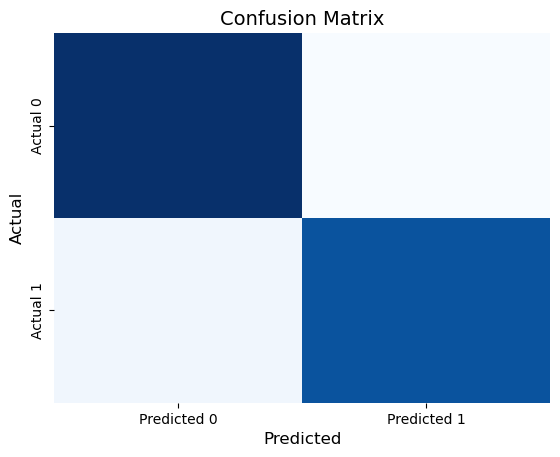

In [46]:
sns.heatmap(confMatrix, fmt="", cmap="Blues", cbar=False,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])

plt.title("Confusion Matrix", fontsize=14)
plt.ylabel("Actual", fontsize=12)
plt.xlabel("Predicted", fontsize=12)
plt.show()

## Great Job!